Curator: Louise Marie Maganto

Reviewer: HERE (Your team member's name)

Title: Stochastic modeling of a mosquito-borne disease

Pathogen: Malaria

DOI: https://doi.org/10.1186/s13662-020-02803-w

Figure: 2 (#Source: see page 12)

Outcome: Successful

Notes: V and J are regarding the mosquito poopuation and dZ is the independent wiener processes for the terms for V and J

In [1]:
variable_names = [ #Source: page 3
    'S',
    'I',
    'R',
    'V',
    'J'     ]
"""Names of the variables in the SDE model. The order of the variables should be the same as the order of the drift and diffusion terms returned by the drift_term and diffusion_term functions."""

parameter_names = [ #Source Table 1 in page 11
    'mu',
    'delta',
    'theta',
    'A',
    'B',
    'a',
    'b',
    'c',
    'k',
    'h',
    'sigma', 
    'zeta'    
    ]
"""Names of the parameters in the SDE model. The order of the parameters should be the same as the order of the values returned by the drift_term and diffusion_term functions."""

initial_values = dict(
    S = 4900,
    I = 95,
    R = 5000,
    V = 238800,
    J = 1200

)
"""Dictionary of initial values for the variables in the SDE model. The keys should be the variable names in variable_names and the values should be the initial values for those variables."""

parameter_values = dict(
    mu = 0.017/365 ,
    delta = 0.042/180 ,
    theta = 0.04,
    A = 10000*(0.017/365),
    B = 240000 * (0.04),
    #changed -5 to -6 to match the paper
    a = 6.417E-6,
    b = 0.075,
    c = 0.0375,
    k = 1/180,
    h = 1/730,
    #Source: page 12 under the figure 2
    sigma = 5E-6,
    zeta = 5E-6

)
"""Dictionary of values for the parameters in the SDE model. The keys should be the parameter names in parameter_names and the values should be the values for those parameters."""

initial_time = 0.0
"""Initial time to simulate during testing and curation of the SDE model."""

final_time = 1400.0
"""Final time to simulate during testing and curation of the SDE model."""


def drift_term(t, y, p):
    """The drift term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The drift term(s) of the SDE model in the same order as variable_names
    """
    s, i, r, v, j = y
    # This paper’s SDE system doesn't use N or M directly in the drift/diffusion equations, so not needed in the code. 
    #n = s + i + r
    #m = v + t 
    mu, delta, theta, A, B, a, b, c, k, h,sigma,zeta  = p
    return [
        A - a * b * s * j + h * r - mu * s,
        #added parenthesis
        a * b * s * j - (mu + k + delta) * i,
        #added parenthesis
        k * i - (mu + h) * r,
        B - a * c * v * i - theta * v,
        a * c * v * i - theta * j

    ]


def diffusion_term(t, y, p):
    """The diffusion term(s) of the SDE model

    Args:
        t: current time
        y: current values of the variables in the same order as variable_names
        p: current values of the parameters in the same order as parameter_names
    Returns:
        list: The diffusion term(s) of the SDE model in the same order as variable_names
    """
    s, i, r, v, j = y
    # This paper’s SDE system doesn't use N or M directly in the drift/diffusion equations, so not needed in the code. 
    #n = s + i + r
    #m = v + t 
    mu, delta, theta, A, B, a, b, c, k, h,sigma,zeta = p
    return [
        - sigma * s * i,
        sigma * s * i,
        r * 0.0,
        - zeta * v *j,
         zeta * v *j

    ]

# End Curation

# Begin Testing

*Do not modify anything below this cell.*

Successful implementations can execute the cells below in order without error to produce a figure.

## Do checks

In [2]:
missing_ics = [n for n in variable_names if n not in initial_values]
missing_params = [n for n in parameter_names if n not in parameter_values]

found_errors = False
if len(missing_ics) > 0:
    print(f"Error: Missing initial values for variables: {missing_ics}")
    found_errors = True
if len(missing_params) > 0:
    print(f"Error: Missing values for parameters: {missing_params}")
    found_errors = True
test_drift = drift_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
test_diffusion = diffusion_term(initial_time, [initial_values[n] for n in variable_names], [parameter_values[n] for n in parameter_names])
if len(test_drift) != len(variable_names):
    print(f"Error: The drift term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_drift)}.")
    found_errors = True
if len(test_diffusion) != len(variable_names):
    print(f"Error: The diffusion term function should return a list of the same length as variable_names. Expected length {len(variable_names)}, but got {len(test_diffusion)}.")
    found_errors = True
if found_errors:
    raise ValueError("Failed to define the SDE model.")

## Do simulation test

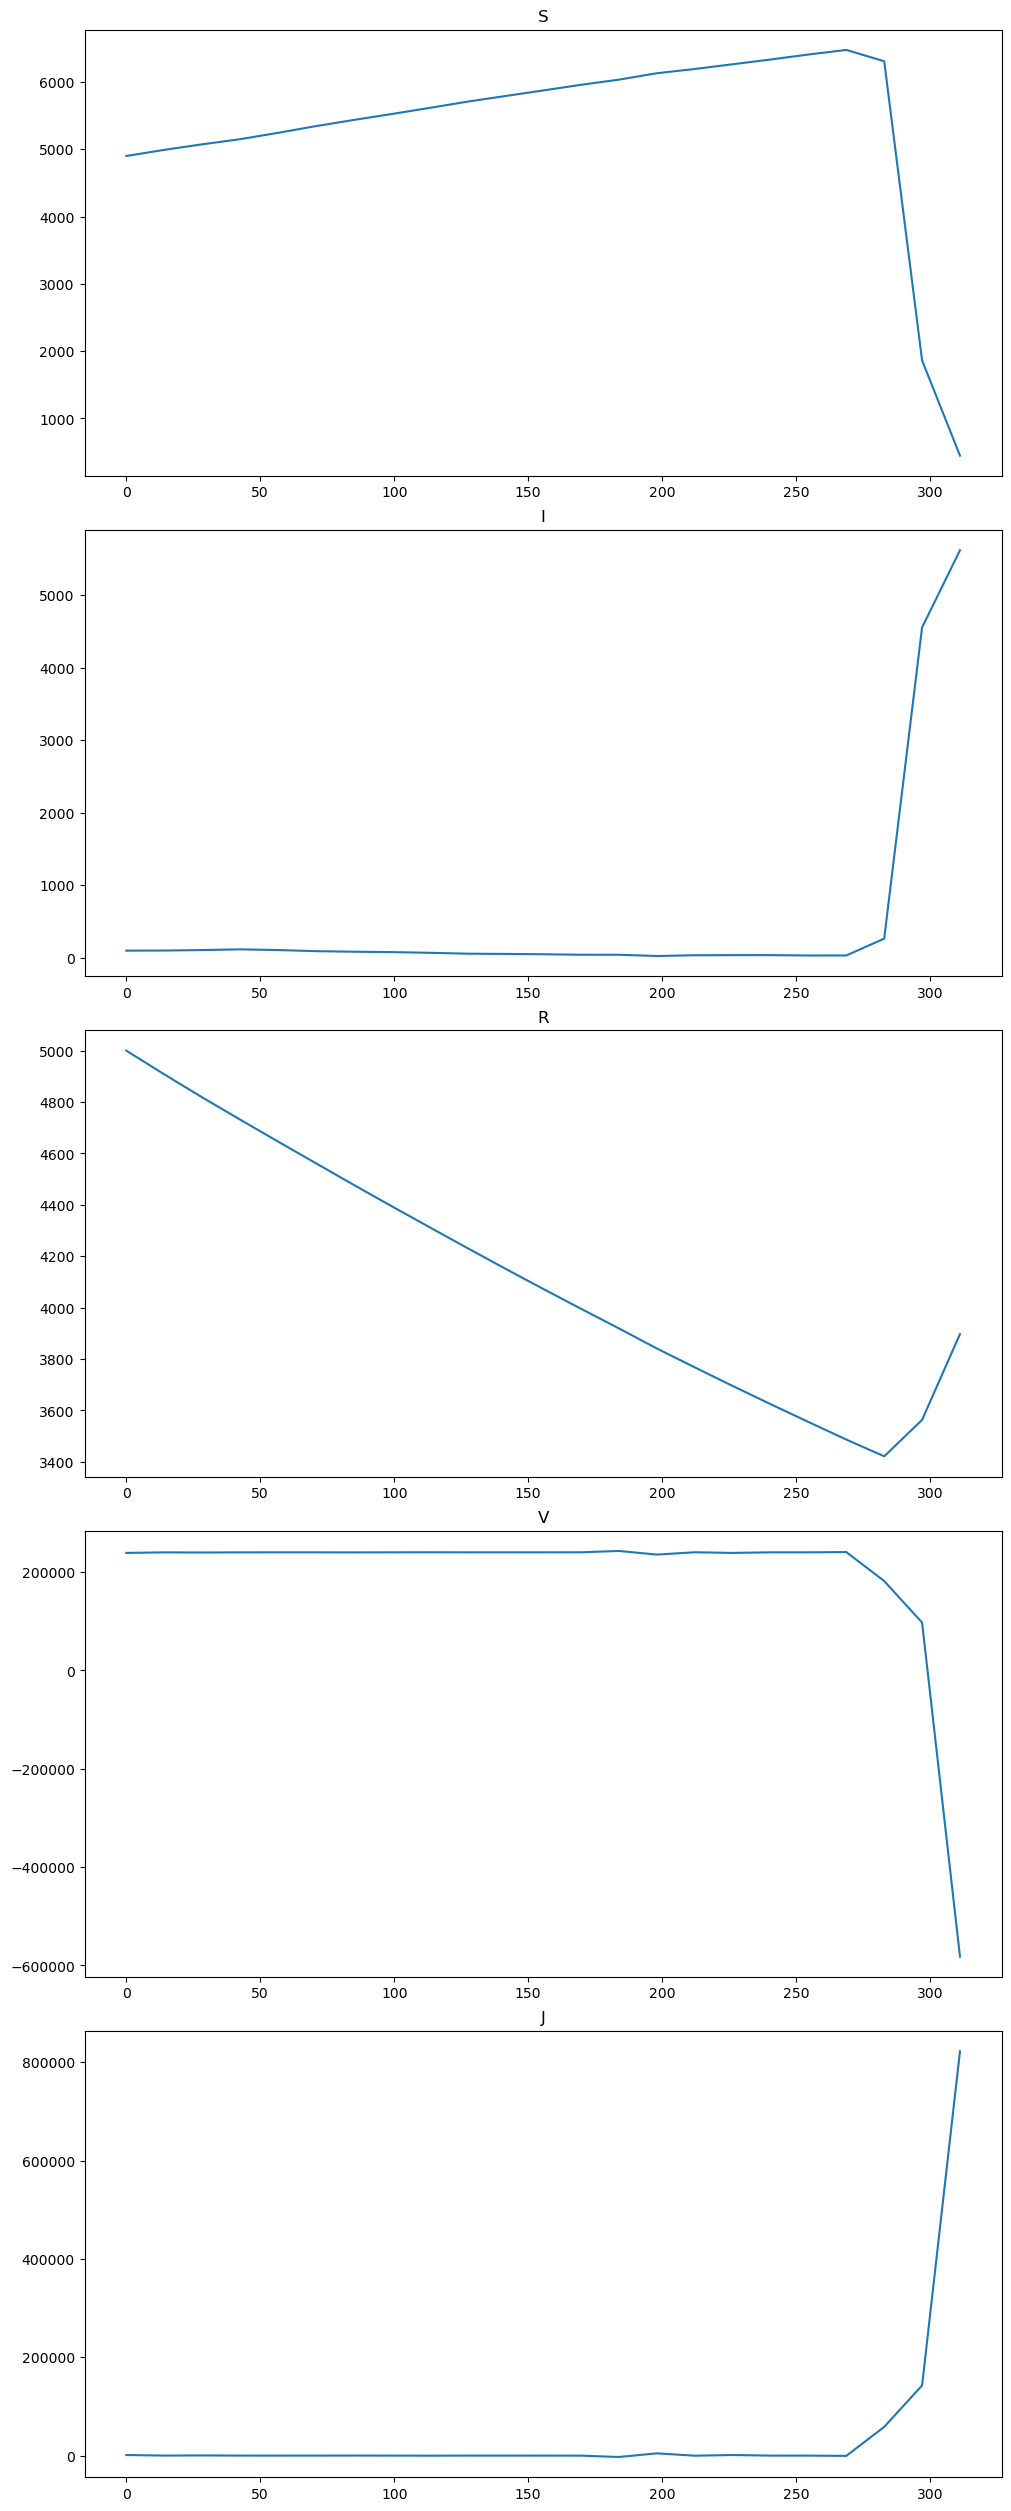

In [3]:
import diffrax
import jax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import numpy as np

sim_times = np.linspace(initial_time, final_time, 100)
dt = (final_time - initial_time) / 1000
dr_term = diffrax.ODETerm(lambda t, y, p: jnp.array(drift_term(t, y, p)))
br_term = diffrax.VirtualBrownianTree(t0=initial_time, t1=final_time, tol=dt / 10, shape=(), key=jax.random.PRNGKey(0))
di_term = diffrax.ControlTerm(lambda t, y, p: jnp.array(diffusion_term(t, y, p)), br_term)
sde_terms = diffrax.MultiTerm(dr_term, di_term)
solver = diffrax.Euler()
solution = diffrax.diffeqsolve(
    sde_terms,
    solver,
    t0=initial_time,
    t1=final_time,
    dt0=dt,
    y0=jnp.asarray([initial_values[n] for n in variable_names]),
    args=jnp.asarray([parameter_values[n] for n in parameter_names]),
    saveat=diffrax.SaveAt(ts=jnp.asarray(sim_times)),
    max_steps=None,
    throw=True
).ys

fig, axs = plt.subplots(len(variable_names), 1, figsize=(10, 5 * len(variable_names)), layout="constrained")
for i, name in enumerate(variable_names):
    axs[i].plot(sim_times, solution[:, i])
    axs[i].set_title(name)

In [4]:
print('Sucessfully defined the SDE model and generated a test simulation plot.')

Sucessfully defined the SDE model and generated a test simulation plot.
